In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

from tp7.tp7 import Tape7
from srfs.srfs import SRFS
import scipy.integrate as integrate
from collections import defaultdict

In [2]:
def modtran_data_files(path: str) -> list:
    files = [path + "/" + file for file in os.listdir(path) if file.endswith(".tp7")]
    return files

a00_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA00")
a41_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA41")
a60_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA60")
a75_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA75")
a85_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA85")

srf = SRFS("./data/libera_srfs_20241017.csv")
tot_wvln = srf.srf_vals['wavelength [um]']
sw_srf = srf.srf_vals[' sw srf']
lw_srf = srf.srf_vals[' lw srf']

def convert(tp7: dict) -> pd.DataFrame:
    new_dfs = [dct.describer_df for dct in tp7.values()]
    return pd.concat(new_dfs, axis=0)

In [3]:
def plot_radiance(rads, title, runnum, s_or_l=1):
    #access wavelength with rads[:,0,runnum], swrad with rads[:,1,runnum], lwrad with rads[:,2,runnum]

    figure = plt.figure(2, figsize=(8,6))
    ax = plt.axes()
    ax.plot(rads[runnum, 0, :], rads[runnum, s_or_l, :], 'r-', label='Radiance')

    ax.legend(prop={"size":20})
    plt.title("%s Radiance Spectrum"%title, fontsize=40)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.xlabel('Wavelength um', fontsize=30)
    plt.ylabel('Radiance $W m^{-2} um^{-1} sr^{-1}$', fontsize=30)
    if s_or_l == 2:
        plt.xlim(0,50)
    else:
        plt.xlim(0,5)

def plot_radiance_2(rads, int_rads, title, runnum, s_or_l=1):
    # access wavelength with rads[runnum, 0, :], swrad with rads[runnum, 1, :], lwrad with rads[runnum, 2, :]

    figure = plt.figure(2, figsize=(8, 6))
    ax = plt.axes()

    # Plot the radiance spectrum
    ax.plot(rads[runnum, 0, :], rads[runnum, s_or_l, :], 'r-', label='Radiance')

    # Plot the integrated radiance or additional radiance curve (modify label as needed)
    ax.plot(rads[runnum, 0, :], int_rads[runnum, :], 'b--', label='Integrated Radiance')

    # Add legend and labels
    ax.legend(prop={"size": 20})
    plt.title("%s Radiance Spectrum" % title, fontsize=40)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.xlabel('Wavelength (μm)', fontsize=30)
    plt.ylabel('Radiance $W m^{-2} μm^{-1} sr^{-1}$', fontsize=30)

    # Set wavelength range based on shortwave or longwave
    if s_or_l == 2:
        plt.xlim(0, 50)
    else:
        plt.xlim(0, 5)


In [4]:
def plot_integrated_radiance(rads, title, idx, wvs, s_or_l=1):
    #access wavelength with rads[:,0,runnum], swrad with rads[:,1,runnum], lwrad with rads[:,2,runnum]

    figure = plt.figure(2, figsize=(10,8))
    ax = plt.axes()
    ax.plot(wvs, rads[idx, :], 'r-', label='Radiance')
    ax.legend(prop={"size":20})
    plt.title("%s Radiance Spectrum"%title, fontsize=40)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.xlabel('Wavelength um', fontsize=30)
    plt.ylabel('Radiance $W m^{-2} um^{-1} sr^{-1}$', fontsize=30)
    if s_or_l == 2:
        plt.xlim(0,50)
    else:
        plt.xlim(0,5)

In [5]:
# a00_data = [Tape7(file, tot_wvln, sw_srf, lw_srf) for file in a00_files]
# titles = [file.title for file in a00_data]
# a00 = {title: file for title, file in zip(titles, a00_data)}
#
# a41_data = [Tape7(file, tot_wvln, sw_srf, lw_srf) for file in a41_files]
# titles = [file.title for file in a41_data]
# a41 = {title: file for title, file in zip(titles, a41_data)}
#
# a60_data = [Tape7(file, tot_wvln, sw_srf, lw_srf) for file in a60_files]
# titles = [file.title for file in a60_data]
# a60 = {title: file for title, file in zip(titles, a60_data)}
#
# a75_data = [Tape7(file, tot_wvln, sw_srf, lw_srf) for file in a75_files]
# titles = [file.title for file in a75_data]
# a75 = {title: file for title, file in zip(titles, a75_data)}

a85_data = [Tape7(file, tot_wvln, sw_srf, lw_srf) for file in a85_files]
titles = [file.title for file in a85_data]
a85 = {title: file for title, file in zip(titles, a85_data)}

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [9]:
snow = a85["Snow"]
tm = snow.rads
snow.rads.shape

(315, 3, 4000)

In [10]:
snow.file_data.shape

(4000, 12, 315)

In [7]:
snow.integrated_rads[0]

array([ 21.77340698,  17.43401601,  16.02002904,  23.18392773,
        18.99387461,  20.44434873,  16.60103666,  15.56654259,
        23.14951558,  18.71573312,  18.59134159,  15.39114817,
        14.75068366,  23.11088827,  18.28882102,  22.19781111,
        17.9884181 ,  16.59437573,  22.94359114,  19.0528085 ,
        20.88711061,  17.25870669,  16.215433  ,  22.91507543,
        18.82803507,  19.06849496,  16.19996618,  15.53094519,
        22.88305686,  18.48268366,  22.00951825,  17.81245031,
        16.47197039,  23.06948056,  19.04287778,  20.69683209,
        17.06520865,  16.08244807,  23.04019973,  18.81201669,
        18.873832  ,  15.98072285,  15.37911462,  23.00731463,
        18.45735292,  22.065241  ,  18.31500934,  17.08036622,
        24.23200261,  19.8225723 ,  20.74435562,  17.49649916,
        16.64752027,  24.19960638,  19.56689107,  18.90355625,
        16.30728511,  15.86664996,  24.16325444,  19.17412161,
        23.07349735,  19.7592789 ,  18.79657414,  26.16

In [13]:
snow.integrated_rads[2]

array([ 16.059889  ,  12.73146951,  11.55659311,  17.24412896,
        13.92459497,  14.98940512,  12.0654225 ,  11.20387135,
        17.22027861,  13.71346883,  13.53296397,  11.1225751 ,
        10.57903511,  17.19332856,  13.39655439,  16.38006652,
        13.17321809,  12.00034487,  17.05152818,  13.96270115,
        15.32309147,  12.58948655,  11.70573977,  17.03175315,
        13.79215531,  13.89109397,  11.76387085,  11.18158952,
        17.00940509,  13.53588366,  16.2398768 ,  13.0365216 ,
        11.90954954,  17.15515876,  13.96129315,  15.18150471,
        12.43879296,  11.60669435,  17.13484895,  13.78611569,
        13.74645745,  11.59314254,  11.06806879,  17.11189307,
        13.52291301,  16.25273134,  13.38541629,  12.34680232,
        18.03041257,  14.53745587,  15.18858129,  12.73078803,
        12.01015546,  18.00792771,  14.34339433,  13.74116147,
        11.80365218,  11.41196946,  17.98253776,  14.05182226,
        16.92808519,  14.40589966,  13.56854716,  19.43

In [ ]:
# for i in range(len(sw_arr)):
#     int_sw_vals.append(scipy.integrate.simpson(sw_arr[i], x = tot_wv))
#     int_sw_filt_vals.append(scipy.integrate.simpson(sw_arr[i]*linear_interpolation_sw_srf, x = total_wavelength))
#     int_updated_sw_filt_vals.append(scipy.integrate.simpson(sw_arr[i]*interp_sw_srf, x = total_wavelength))
    #integrated_ceres_sw_filter_array.append(scipy.integrate.simpson(sw_arr[i]*interp_sw_srf, x = total_wavelength))

In [6]:
a85

{'Land': <tp7.tp7.Tape7 at 0x30a516c90>,
 'Clear Ocean': <tp7.tp7.Tape7 at 0x12c084e50>,
 'Snow': <tp7.tp7.Tape7 at 0x12c020d10>,
 'Deep Convective Cloud': <tp7.tp7.Tape7 at 0x338ade050>,
 'Cloudy Ocean': <tp7.tp7.Tape7 at 0x10c801050>}

In [7]:
land_a00 = a00["Land"]
land_a00.rads.shape # runs, wv, data

(630, 3, 4000)

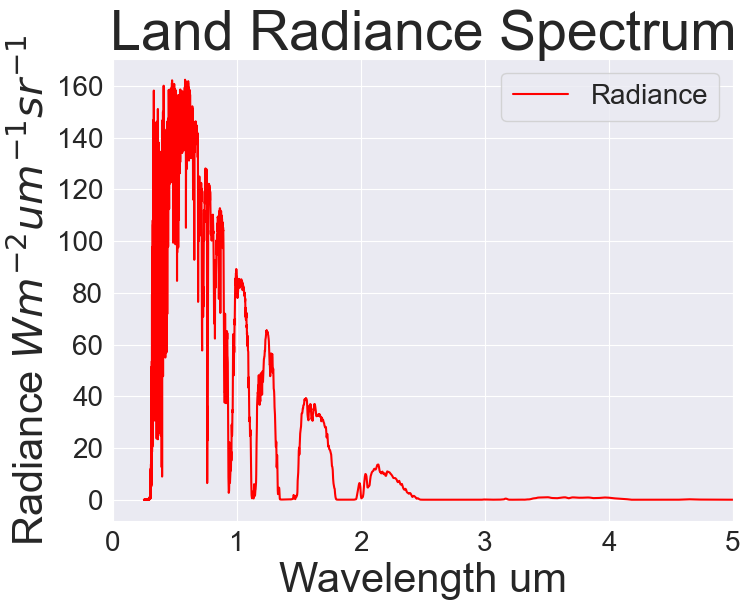

In [15]:
plot_radiance(dc.rads, land_a00.title, 0, s_or_l=1)

In [8]:
land_a00.describer_df

,Scene,SZA,VZA,RAZ,Cloud,Run #,Shortwave Unfiltered Rads (Integrated),Longwave Unfiltered Rads (Integrated),Shortwave Filtered Rads (Integrated),Longwave Filtered Rads (Integrated)
0,Land,0.0,0.000,0.0,0,0,101.967819,98.435473,75.727145,0.016809
1,Land,0.0,0.000,0.0,1,1,103.227094,69.392565,75.293403,0.003139
2,Land,0.0,0.000,0.0,1,2,155.619541,60.644086,113.325768,0.002398
3,Land,0.0,0.000,0.0,1,3,250.712675,93.578042,183.088022,0.021329
4,Land,0.0,0.000,0.0,1,4,339.815605,86.650577,247.891967,0.029803
...,...,...,...,...,...,...,...,...,...,...
625,Land,0.0,79.914,172.5,0,625,72.466530,58.907500,52.043946,0.001230
626,Land,0.0,79.914,172.5,1,626,83.026982,46.597913,59.707949,0.002290
627,Land,0.0,79.914,172.5,1,627,106.881209,44.111608,77.204551,0.002583
628,Land,0.0,79.914,172.5,1,628,157.489675,58.372397,114.987698,0.008196


In [9]:
a00["Snow"].describer_df

,Scene,SZA,VZA,RAZ,Cloud,Run #,Shortwave Unfiltered Rads (Integrated),Longwave Unfiltered Rads (Integrated),Shortwave Filtered Rads (Integrated),Longwave Filtered Rads (Integrated)
0,Snow,0.000,0.000,0.0,0,0,1.602011e-06,0.000491,1.233818e-06,5.401733e-10
1,Snow,0.000,0.000,0.0,1,1,1.618549e-06,0.000483,1.243242e-06,3.165444e-09
2,Snow,0.000,0.000,0.0,1,2,1.534858e-06,0.000492,1.177596e-06,5.126559e-10
3,Snow,0.000,0.000,0.0,1,3,2.903169e-06,0.000469,2.209365e-06,6.147627e-08
4,Snow,0.000,0.000,0.0,1,4,2.261459e-06,0.000490,1.728870e-06,2.828023e-08
...,...,...,...,...,...,...,...,...,...,...
310,Snow,9.156,89.947,172.5,0,310,6.375241e-07,0.000448,4.811997e-07,1.389037e-10
311,Snow,9.156,89.947,172.5,1,311,7.528710e-07,0.000417,5.559778e-07,1.634299e-08
312,Snow,9.156,89.947,172.5,1,312,5.552769e-07,0.000446,4.189763e-07,2.539906e-10
313,Snow,9.156,89.947,172.5,1,313,2.247316e-06,0.000437,1.738242e-06,3.679796e-08


In [23]:
sza00 = [dct.describer_df for dct in a00.values()]
sza00 = pd.concat(sza00, axis=0)
sza00

,Scene,SZA,VZA,RAZ,Cloud,Run #,Shortwave Unfiltered Rads (Integrated),Longwave Unfiltered Rads (Integrated),Shortwave Filtered Rads (Integrated),Longwave Filtered Rads (Integrated)
0,Land,85.000,0.000,0.0,0,0,8.312447e+00,98.435431,6.062306e+00,3.342205e-04
1,Land,85.000,0.000,0.0,1,1,8.976469e+00,69.392603,6.505601e+00,2.766002e-04
2,Land,85.000,0.000,0.0,1,2,1.148042e+01,60.644071,8.353203e+00,3.181347e-04
3,Land,85.000,0.000,0.0,1,3,1.436688e+01,93.578245,1.045812e+01,4.108197e-04
4,Land,85.000,0.000,0.0,1,4,1.994112e+01,86.650246,1.464458e+01,2.159560e-03
...,...,...,...,...,...,...,...,...,...,...
79,Cloudy Ocean,84.092,89.947,142.5,1,79,5.495387e-07,0.000475,4.264091e-07,3.312347e-09
80,Cloudy Ocean,83.845,89.947,172.5,1,80,5.875353e-07,0.000460,4.589614e-07,1.550701e-09
81,Cloudy Ocean,83.845,89.947,172.5,1,81,6.149711e-07,0.000455,4.802549e-07,1.849066e-09
82,Cloudy Ocean,83.845,89.947,172.5,1,82,4.518198e-07,0.000476,3.508038e-07,1.036812e-10


In [61]:
sza85 = [dct.describer_df for dct in a85.values()]
sza85 = pd.concat(sza85, axis=0)
sza85

,Scene,SZA,VZA,RAZ,Cloud,Run #,Shortwave Unfiltered Rads (Integrated),Longwave Unfiltered Rads (Integrated),Shortwave Filtered Rads (Integrated),Longwave Filtered Rads (Integrated)
0,Land,85.000,0.000,0.0,0,0,8.312447e+00,98.435431,6.062306e+00,3.342205e-04
1,Land,85.000,0.000,0.0,1,1,8.976469e+00,69.392603,6.505601e+00,2.766002e-04
2,Land,85.000,0.000,0.0,1,2,1.148042e+01,60.644071,8.353203e+00,3.181347e-04
3,Land,85.000,0.000,0.0,1,3,1.436688e+01,93.578245,1.045812e+01,4.108197e-04
4,Land,85.000,0.000,0.0,1,4,1.994112e+01,86.650246,1.464458e+01,2.159560e-03
...,...,...,...,...,...,...,...,...,...,...
79,Cloudy Ocean,84.092,89.947,142.5,1,79,5.495387e-07,0.000475,4.264091e-07,3.312347e-09
80,Cloudy Ocean,83.845,89.947,172.5,1,80,5.875353e-07,0.000460,4.589614e-07,1.550701e-09
81,Cloudy Ocean,83.845,89.947,172.5,1,81,6.149711e-07,0.000455,4.802549e-07,1.849066e-09
82,Cloudy Ocean,83.845,89.947,172.5,1,82,4.518198e-07,0.000476,3.508038e-07,1.036812e-10


In [53]:
sza00.columns

Index(['Scene', 'SZA', 'VZA', 'RAZ', 'Cloud', 'Run #',
       'Shortwave Unfiltered Rads (Integrated)',
       'Longwave Unfiltered Rads (Integrated)',
       'Shortwave Filtered Rads (Integrated)',
       'Longwave Filtered Rads (Integrated)'],
      dtype='object')

In [38]:
dc = a00["Deep Convective Cloud"]
dc.describer_df

,Scene,SZA,VZA,RAZ,Cloud,Run #,Shortwave Unfiltered Rads (Integrated),Longwave Unfiltered Rads (Integrated),Shortwave Filtered Rads (Integrated),Longwave Filtered Rads (Integrated)
0,Deep Convective Cloud,85.000,0.00000,0.0,1,0,20.163600,27.945048,14.825230,0.000670
1,Deep Convective Cloud,85.000,0.00000,0.0,1,1,20.550756,28.648690,15.114731,0.000633
2,Deep Convective Cloud,85.000,0.00000,0.0,1,2,20.607431,31.656736,15.142934,0.000530
3,Deep Convective Cloud,85.506,29.49001,7.5,1,3,20.025927,28.077062,14.750117,0.001263
4,Deep Convective Cloud,85.506,29.49001,7.5,1,4,20.320229,28.757337,14.965945,0.001216
...,...,...,...,...,...,...,...,...,...,...
58,Deep Convective Cloud,76.998,79.91400,142.5,1,58,62.199197,31.861680,44.879454,0.001803
59,Deep Convective Cloud,76.998,79.91400,142.5,1,59,63.972217,34.170336,46.139023,0.002402
60,Deep Convective Cloud,75.000,79.91400,172.5,1,60,70.008544,31.318456,50.496875,0.001818
61,Deep Convective Cloud,75.000,79.91400,172.5,1,61,71.543522,31.861702,51.509119,0.001746


In [39]:
dc_00 = dc.describer_df
dc_00

,Scene,SZA,VZA,RAZ,Cloud,Run #,Shortwave Unfiltered Rads (Integrated),Longwave Unfiltered Rads (Integrated),Shortwave Filtered Rads (Integrated),Longwave Filtered Rads (Integrated)
0,Deep Convective Cloud,85.000,0.00000,0.0,1,0,20.163600,27.945048,14.825230,0.000670
1,Deep Convective Cloud,85.000,0.00000,0.0,1,1,20.550756,28.648690,15.114731,0.000633
2,Deep Convective Cloud,85.000,0.00000,0.0,1,2,20.607431,31.656736,15.142934,0.000530
3,Deep Convective Cloud,85.506,29.49001,7.5,1,3,20.025927,28.077062,14.750117,0.001263
4,Deep Convective Cloud,85.506,29.49001,7.5,1,4,20.320229,28.757337,14.965945,0.001216
...,...,...,...,...,...,...,...,...,...,...
58,Deep Convective Cloud,76.998,79.91400,142.5,1,58,62.199197,31.861680,44.879454,0.001803
59,Deep Convective Cloud,76.998,79.91400,142.5,1,59,63.972217,34.170336,46.139023,0.002402
60,Deep Convective Cloud,75.000,79.91400,172.5,1,60,70.008544,31.318456,50.496875,0.001818
61,Deep Convective Cloud,75.000,79.91400,172.5,1,61,71.543522,31.861702,51.509119,0.001746


In [6]:
def plot_filtered_data_analysis(df, scenes_to_plot=None):
    """
    Plot analysis of filtered vs unfiltered radiation data from DataFrame

    Parameters:
    df: pandas DataFrame with columns for Scene, SZA, VZA, RAZ, Cloud, Run #,
        and various radiation measurements
    scenes_to_plot: list of scene names to plot (optional)
    """
    # If no scenes specified, use all scenes
    if scenes_to_plot is None:
        scenes = df['Scene'].unique()
    else:
        # Filter scenes based on provided list
        scenes = [scene for scene in df['Scene'].unique() if scene in scenes_to_plot]

    for scene in scenes:
        scene_data = df[df['Scene'] == scene]
        print(scene_data.shape)

        # Group by VZA and RAZ combinations
        grouped = scene_data.groupby(['VZA', 'RAZ'])

        for (vza, raz), group in grouped:
            # Rest of the plotting code remains the same as previous artifact
            sw_unfiltered = group['Shortwave Unfiltered Rads (Integrated)'].values
            sw_filtered = group['Shortwave Filtered Rads (Integrated)'].values

            coefficients = np.polynomial.polynomial.polyfit(sw_filtered, sw_unfiltered, 2)
            sw_filter_fit = np.polynomial.polynomial.polyval(sw_filtered, coefficients)

            # print(scene,"\n\n VZA: \n",  vza, "\n\n  RAZ \n ", raz, "\n\n  SW unfilt \n", sw_unfiltered, "\n\n sw filt fit \n", sw_filter_fit)

            # fig, axs = plt.subplots(2, 2, figsize=(10, 8))
            plt.figure(figsize=(10, 6))
            plt.plot(sw_unfiltered, sw_filter_fit,
                    label='Second order polynomial fit', color='blue')
            plt.scatter(sw_filter_fit, sw_unfiltered,
                       label='Fitted values', color='green', alpha=0.5)
            plt.scatter(sw_unfiltered, sw_filtered,
                       label='Original integrated radiances', color='red', alpha=0.5)

            plt.xlabel("Unfiltered wavelength integrated values [W/m2/sr]")
            plt.ylabel("Filtered integrated values [W/m2/sr]")

            # Set plot limits based on scene type
            # if 'OCEAN_CLOUD' in scene.upper():
            #     plt.xlim([0, 300])
            #     plt.ylim([0, 300])
            # elif 'OCEAN_CLEAR' in scene.upper():
            #     plt.xlim([0, 200])
            #     plt.ylim([0, 200])
            # elif 'SNOW' in scene.upper():
            #     plt.xlim([5, 5])
            #     plt.ylim([5, 5])

            plt.title(f"{scene} at SZA=85, VZA={vza:.1f}, RAZ={raz:.1f}")
            plt.legend()
            plt.grid(True)
            plt.show()

In [16]:
a85_ds = convert(a85)

In [21]:
a85_ds.columns

Index(['Scene', 'SZA', 'VZA', 'RAZ', 'Cloud', 'Run #',
       'Shortwave Unfiltered Rads (Integrated)',
       'Longwave Unfiltered Rads (Integrated)',
       'Shortwave Filtered Rads (Integrated)',
       'Longwave Filtered Rads (Integrated)'],
      dtype='object')

In [47]:
# plot_filtered_data_analysis(a85_ds, ["Snow"])

In [6]:
ocncld60 = a60["Cloudy Ocean"]

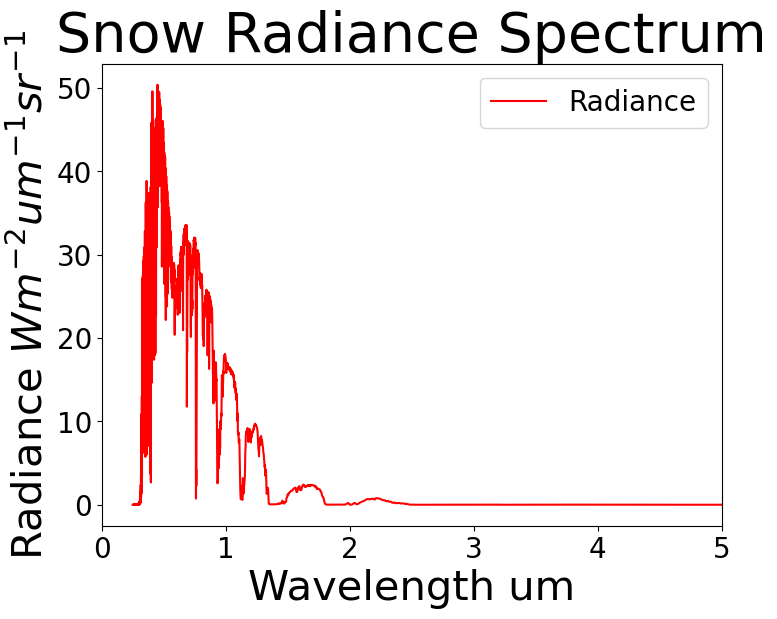

In [13]:
plot_radiance(snow.rads, snow.title, 0)

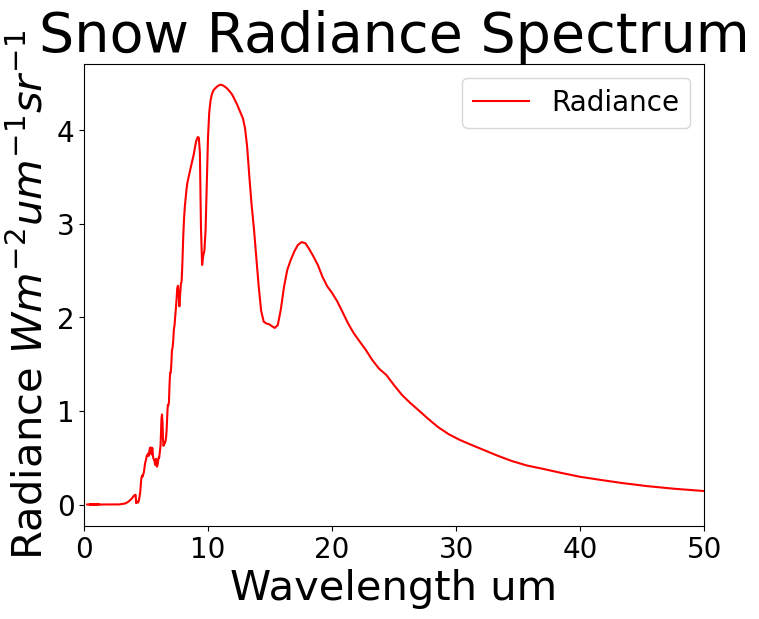

In [16]:
plot_radiance(snow.rads, snow.title, 0, 2)

In [11]:
%run ./tp7/fergus_code/spectra_describer.py

temp = ddf
rf = rads

(4000, 12, 315)
sza [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0.]
    Scene     SZA   

(315, 3, 4000)

In [24]:
for i in snow.rads[0][1]:
    print(i)

0.0035505600000000003
0.0033460063692299998
0.0034109864536
0.000862193253712
0.00317508030144
0.002605314481
0.0035668752496
0.00269900861472
0.00266865327744
0.00218150997376
0.00316491588
0.000991722941325
0.000702756410928
0.0019523674765799998
0.00221433787652
0.0032379778775
0.00400599869184
0.00259809460953
0.001385224320964
0.001196662194027
0.0018458818120000002
0.00167475560898
0.00309653502912
0.00185733500047
0.00073881379936
0.0018354006
0.0015599057792239999
0.000481418449771
0.00161333393184
0.001052948588934
0.0007793607441
0.00163295193726
0.0008446103224319999
0.00292772803756
0.00180853835688
0.00201907692675
0.000994698776688
0.0006874082957609999
0.001020004213676
0.001142761951556
0.000647571672
0.0015075573333040001
0.0016472550845999998
0.001297581604479
0.001044805377296
0.0008155126154000001
0.000798950229948
0.000718008677341
0.000868815014912
0.0008797397587559999
0.0013340293525
0.00198503676129
0.00158376499344
0.00308709679144
0.0032702037783199998
0.0017

In [9]:
ddf

,Scene,SZA,VZA,RAZ,Sfc Temp,Albedo model,Cld Type,Cld Alt (km),Cld Thick (km),Cld Ext Coef (km-1),Run #
0,Snow,84.822,0.000,0.0,257.2,-10.0,No cloud,0.0,0.0,0.0,0
1,Snow,84.822,0.000,0.0,257.2,-10.0,ICLD 19: subvisual cirrus cloud,10.0,0.3,1.0,1
2,Snow,84.822,0.000,0.0,257.2,-10.0,ICLD 18: cirrus cloud,0.5,1.0,2.0,2
3,Snow,84.822,0.000,0.0,257.2,-10.0,ICLD 3: stratus cloud,0.1,3.0,30.0,3
4,Snow,84.822,0.000,0.0,257.2,-10.0,ICLD 4: strato-cumulus cloud,0.1,0.4,10.0,4
...,...,...,...,...,...,...,...,...,...,...,...
310,Snow,83.928,89.947,172.5,270.0,-12.0,No cloud,0.0,0.0,0.0,310
311,Snow,83.928,89.947,172.5,270.0,-12.0,ICLD 19: subvisual cirrus cloud,10.0,0.3,1.0,311
312,Snow,83.928,89.947,172.5,270.0,-12.0,ICLD 18: cirrus cloud,0.5,1.0,2.0,312
313,Snow,83.928,89.947,172.5,270.0,-12.0,ICLD 3: stratus cloud,0.1,3.0,30.0,313


In [10]:
snow.describer_df

,Scene,SZA,VZA,RAZ,Cloud,Run #,Shortwave Unfiltered Rads (Integrated),Longwave Unfiltered Rads (Integrated),Shortwave Filtered Rads (Integrated),Longwave Filtered Rads (Integrated)
0,Snow,84.822,0.000,0.0,0,0,21.773407,64.163561,16.059889,41.737298
1,Snow,84.822,0.000,0.0,1,1,17.434016,61.352730,12.731470,39.954763
2,Snow,84.822,0.000,0.0,1,2,16.020029,65.101014,11.556593,42.320141
3,Snow,84.822,0.000,0.0,1,3,23.183928,53.795441,17.244129,35.158961
4,Snow,84.822,0.000,0.0,1,4,18.993875,63.364916,13.924595,41.263277
...,...,...,...,...,...,...,...,...,...,...
310,Snow,83.928,89.947,172.5,0,310,72.642480,55.204991,51.297390,35.892922
311,Snow,83.928,89.947,172.5,1,311,92.298272,42.378937,67.032751,27.649945
312,Snow,83.928,89.947,172.5,1,312,87.839910,53.257830,63.199045,34.697747
313,Snow,83.928,89.947,172.5,1,313,113.020691,47.220680,83.440846,30.930216


In [11]:
np.shape(rads)

(4000, 3, 315)

In [12]:
rf.shape, tm.shape

((4000, 3, 315), (315, 3, 4000))

In [13]:
rf_r = rf[:, 0, 0][::-1]
tm_r = tm[0, 1, :]

In [17]:
wvf = rf[:, 0, 0][::-1]
tm_wv = tm[0, 0, :]

In [14]:
for i in tm_r:
    print(i)

0.0035505600000000003
0.0033460063692299998
0.0034109864536
0.000862193253712
0.00317508030144
0.002605314481
0.0035668752496
0.00269900861472
0.00266865327744
0.00218150997376
0.00316491588
0.000991722941325
0.000702756410928
0.0019523674765799998
0.00221433787652
0.0032379778775
0.00400599869184
0.00259809460953
0.001385224320964
0.001196662194027
0.0018458818120000002
0.00167475560898
0.00309653502912
0.00185733500047
0.00073881379936
0.0018354006
0.0015599057792239999
0.000481418449771
0.00161333393184
0.001052948588934
0.0007793607441
0.00163295193726
0.0008446103224319999
0.00292772803756
0.00180853835688
0.00201907692675
0.000994698776688
0.0006874082957609999
0.001020004213676
0.001142761951556
0.000647571672
0.0015075573333040001
0.0016472550845999998
0.001297581604479
0.001044805377296
0.0008155126154000001
0.000798950229948
0.000718008677341
0.000868815014912
0.0008797397587559999
0.0013340293525
0.00198503676129
0.00158376499344
0.00308709679144
0.0032702037783199998
0.0017

In [15]:
for i in rf_r:
    print(i)

0.0035505600000000003
0.0033460063692299998
0.0034109864536
0.000862193253712
0.00317508030144
0.002605314481
0.0035668752496
0.00269900861472
0.00266865327744
0.00218150997376
0.00316491588
0.000991722941325
0.000702756410928
0.0019523674765799998
0.00221433787652
0.0032379778775
0.00400599869184
0.00259809460953
0.001385224320964
0.001196662194027
0.0018458818120000002
0.00167475560898
0.00309653502912
0.00185733500047
0.00073881379936
0.0018354006
0.0015599057792239999
0.000481418449771
0.00161333393184
0.001052948588934
0.0007793607441
0.00163295193726
0.0008446103224319999
0.00292772803756
0.00180853835688
0.00201907692675
0.000994698776688
0.0006874082957609999
0.001020004213676
0.001142761951556
0.000647571672
0.0015075573333040001
0.0016472550845999998
0.001297581604479
0.001044805377296
0.0008155126154000001
0.000798950229948
0.000718008677341
0.000868815014912
0.0008797397587559999
0.0013340293525
0.00198503676129
0.00158376499344
0.00308709679144
0.0032702037783199998
0.0017

In [16]:
sum([1 if tm_r[i] == rf_r[i] else 0 for i in range(len(tm_r))])

4000

In [19]:
for i in wvf:
    print(i)

0.25
0.2500625156289072
0.25012506253126565
0.25018764073054794
0.2502502502502503
0.2503128911138924
0.25037556334501754
0.2504382669671926
0.250501002004008
0.25056376847907796
0.2506265664160401
0.25068939583855604
0.25075225677031093
0.2508151492350138
0.2508780732563974
0.25094102885821834
0.25100401606425704
0.25106703489831783
0.25113008538422904
0.25119316754584275
0.25125628140703515
0.25131942699170645
0.2513826043237808
0.25144581342720645
0.2515090543259557
0.25157232704402516
0.25163563160543534
0.2516989680342311
0.25176233635448136
0.2518257365902795
0.2518891687657431
0.25195263290501385
0.25201612903225806
0.25207965717166625
0.2521432173474533
0.25220680958385877
0.2522704339051463
0.25233409033560433
0.2523977788995457
0.25246149962130776
0.25252525252525254
0.2525890376357666
0.25265285497726125
0.25271670457417234
0.2527805864509606
0.2528445006321113
0.25290844714213456
0.25297242600556535
0.25303643724696356
0.2531004808909137
0.25316455696202533
0.25322866548493

In [20]:
for i in tm_wv:
    print(i)

0.25
0.2500625156289072
0.25012506253126565
0.25018764073054794
0.2502502502502503
0.2503128911138924
0.25037556334501754
0.2504382669671926
0.250501002004008
0.25056376847907796
0.2506265664160401
0.25068939583855604
0.25075225677031093
0.2508151492350138
0.2508780732563974
0.25094102885821834
0.25100401606425704
0.25106703489831783
0.25113008538422904
0.25119316754584275
0.25125628140703515
0.25131942699170645
0.2513826043237808
0.25144581342720645
0.2515090543259557
0.25157232704402516
0.25163563160543534
0.2516989680342311
0.25176233635448136
0.2518257365902795
0.2518891687657431
0.25195263290501385
0.25201612903225806
0.25207965717166625
0.2521432173474533
0.25220680958385877
0.2522704339051463
0.25233409033560433
0.2523977788995457
0.25246149962130776
0.25252525252525254
0.2525890376357666
0.25265285497726125
0.25271670457417234
0.2527805864509606
0.2528445006321113
0.25290844714213456
0.25297242600556535
0.25303643724696356
0.2531004808909137
0.25316455696202533
0.25322866548493

In [21]:
integrate.simpson(y=tm_r, x=tm_wv)

21.773406980842225

In [22]:
integrate.simpson(y=rf_r, x=wvf)

21.773406980842225

In [22]:
a85_ds.columns

Index(['Scene', 'SZA', 'VZA', 'RAZ', 'Cloud', 'Run #',
       'Shortwave Unfiltered Rads (Integrated)',
       'Longwave Unfiltered Rads (Integrated)',
       'Shortwave Filtered Rads (Integrated)',
       'Longwave Filtered Rads (Integrated)'],
      dtype='object')

Text(0, 0.5, 'Radiance $W m^{-2} um^{-1} sr^{-1}$')

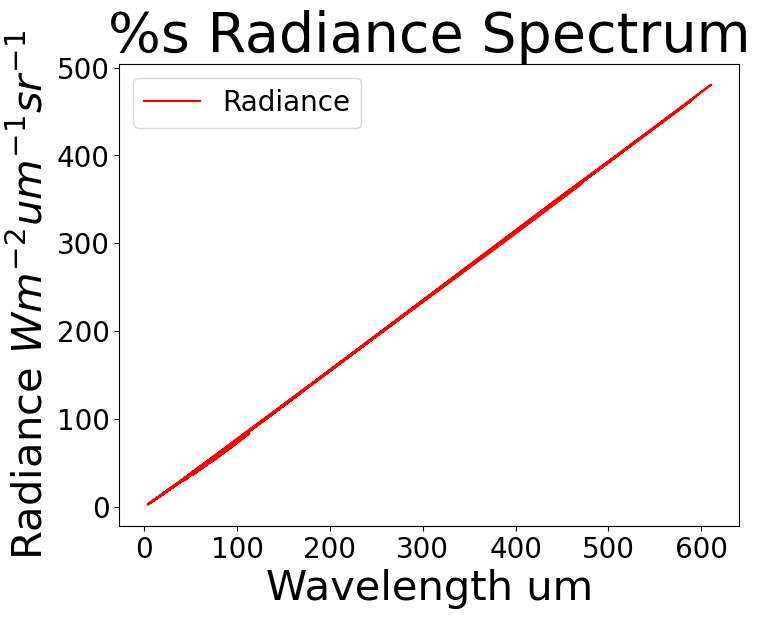

In [23]:
figure = plt.figure(2, figsize=(8,6))
ax = plt.axes()
ax.plot(a85_ds["Shortwave Unfiltered Rads (Integrated)"], a85_ds["Shortwave Filtered Rads (Integrated)"], 'r-', label='Radiance')

ax.legend(prop={"size":20})
plt.title("%s Radiance Spectrum", fontsize=40)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('Wavelength um', fontsize=30)
plt.ylabel('Radiance $W m^{-2} um^{-1} sr^{-1}$', fontsize=30)

In [51]:
# def plot_aggregate_radiation(df, scene_type=None):
#     """
#     Create an aggregate plot of unfiltered vs filtered radiation values
#
#     Parameters:
#     df: pandas DataFrame with radiation measurements
#     scene_type: Optional string to filter specific scene types
#     """
#     plt.figure(figsize=(10, 8))
#
#     # Filter dataframe if scene_type is specified
#     if scene_type:
#         df = df[df['Scene'].str.contains(scene_type, case=False)]
#
#     # Scatter plot of all data points
#     plt.scatter(
#         df['Shortwave Unfiltered Rads (Integrated)'],
#         df['Shortwave Filtered Rads (Integrated)'],
#         label='Integrated values',
#         color='orange',
#         alpha=0.7
#     )
#
#     # Perform polynomial fit on entire dataset
#     unfiltered = df['Shortwave Unfiltered Rads (Integrated)']
#     filtered = df['Shortwave Filtered Rads (Integrated)']
#
#     coefficients = np.polynomial.polynomial.polyfit(filtered, unfiltered, 2)
#     fit_line = np.polynomial.polynomial.polyval(filtered, coefficients)
#
#     # Plot polynomial fit line
#     plt.plot(
#         unfiltered,
#         fit_line,
#         color='blue',
#         label='Second order polynomial fit, Libera'
#     )
#
#     plt.xlabel('Total unfiltered integrated values')
#     plt.ylabel('Total filtered integrated values')
#
#     # Determine appropriate title and limits
#     if scene_type:
#         title = f"{scene_type} 85 Radiation Analysis"
#     else:
#         title = "Aggregate Radiation Analysis"
#
#     plt.title(title)
#     plt.legend()
#
#     # Set equal x and y limits for symmetry
#     max_val = max(plt.xlim()[1], plt.ylim()[1])
#     plt.xlim(0, max_val)
#     plt.ylim(0, max_val)
#
#     plt.grid(True, linestyle='--', alpha=0.7)
#     plt.show()

In [25]:
# def plot_scene_radiation(df, scene_type):
#     """Plot radiation data aggregated by scene"""
#     scene_data = df[df['Scene'].str.contains(scene_type, case=False)]
#
#     plt.figure(figsize=(10, 8))
#
#     # Get all filtered and unfiltered values for the scene
#     unfiltered = scene_data['Shortwave Unfiltered Rads (Integrated)']
#     filtered = scene_data['Shortwave Filtered Rads (Integrated)']
#
#     # Calculate polynomial fit
#     coefficients = np.polynomial.polynomial.polyfit(filtered, unfiltered, 2)
#     fit_line = np.polynomial.polynomial.polyval(filtered, coefficients)
#
#     # Plot data and fit
#     plt.scatter(unfiltered, filtered, color='orange', label='Filtered values', alpha=0.7)
#     plt.plot(unfiltered, fit_line, color='blue', label='Second order polynomial fit')
#
#     plt.xlabel('Total unfiltered integrated values')
#     plt.ylabel('Total filtered integrated values')
#     plt.title(f"{scene_type.upper()} SZA 85 ")
#     plt.legend()
#
#     # Set equal axes limits
#     max_val = max(plt.xlim()[1], plt.ylim()[1])
#     plt.xlim(0, max_val)
#     plt.ylim(0, max_val)
#
#     plt.grid(True, linestyle='--', alpha=0.7)
#     plt.show()
def plot_scene_radiation(df, scene_type):
    """Plot radiation data aggregated by scene with distinct colors"""
    ret = {}
    scene_data = df[df['Scene'] == "Snow"]
    ret["df"] = scene_data

    plt.figure(figsize=(10, 8))

    unfiltered = scene_data['Shortwave Unfiltered Rads (Integrated)']
    filtered = scene_data['Shortwave Filtered Rads (Integrated)']
    ret["unfiltered"] = unfiltered
    ret["filtered"] = filtered

    # coefficients = np.polynomial.polynomial.polyfit(filtered, unfiltered, 2)
    # fit_line = np.polynomial.polynomial.polyval(filtered, coefficients)

    plt.scatter(unfiltered, filtered, color='orange', label='Filtered values', alpha=0.7)
    plt.scatter(unfiltered, unfiltered, color='blue', label='Unfiltered values', alpha=0.7)
    # plt.plot(unfiltered, fit_line, color='red', label='Second order polynomial fit')

    plt.xlabel('Total unfiltered integrated values')
    plt.ylabel('Total filtered integrated values')
    plt.title(f"{scene_type.upper()} SZA 85 Rads")
    plt.legend()

    # max_val = max(plt.xlim()[1], plt.ylim()[1])
    # print(plt.xlim(), plt.ylim())
    # plt.xlim(0, max_val)
    # plt.ylim(0, max_val)

    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
    return ret

In [11]:
a85_ds = convert(a85)

In [12]:
a85_ds[a85_ds["Scene"] == "Snow"]

,Scene,SZA,VZA,RAZ,Cloud,Run #,Shortwave Unfiltered Rads (Integrated),Longwave Unfiltered Rads (Integrated),Shortwave Filtered Rads (Integrated),Longwave Filtered Rads (Integrated)
0,Snow,84.822,0.000,0.0,0,0,21.773407,64.163561,16.059889,41.737298
1,Snow,84.822,0.000,0.0,1,1,17.434016,61.352730,12.731470,39.954763
2,Snow,84.822,0.000,0.0,1,2,16.020029,65.101014,11.556593,42.320141
3,Snow,84.822,0.000,0.0,1,3,23.183928,53.795441,17.244129,35.158961
4,Snow,84.822,0.000,0.0,1,4,18.993875,63.364916,13.924595,41.263277
...,...,...,...,...,...,...,...,...,...,...
310,Snow,83.928,89.947,172.5,0,310,72.642480,55.204991,51.297390,35.892922
311,Snow,83.928,89.947,172.5,1,311,92.298272,42.378937,67.032751,27.649945
312,Snow,83.928,89.947,172.5,1,312,87.839910,53.257830,63.199045,34.697747
313,Snow,83.928,89.947,172.5,1,313,113.020691,47.220680,83.440846,30.930216


In [24]:
snow = a85["Snow"]
snow.integrated_rads.shape

(4, 315)

In [26]:
snow.integrated_rads[0]

array([1.41451271e-07, 1.17743592e-07, 8.15114627e-08, 2.04963577e-07,
       1.35304474e-07, 1.16526389e-07, 1.03072766e-07, 7.61565801e-08,
       2.04863201e-07, 1.32759605e-07, 9.32198298e-08, 8.87909595e-08,
       6.84499146e-08, 2.04756658e-07, 1.29812485e-07, 1.44161488e-07,
       1.36245111e-07, 8.82603368e-08, 2.03584749e-07, 1.35986411e-07,
       1.19443612e-07, 1.23382540e-07, 8.38332210e-08, 2.03501488e-07,
       1.33940196e-07, 9.63789213e-08, 1.10845891e-07, 7.74011619e-08,
       2.03413115e-07, 1.31562490e-07, 1.43048073e-07, 1.31669023e-07,
       8.70924578e-08, 2.05502634e-07, 1.36574264e-07, 1.18321421e-07,
       1.18500347e-07, 8.25377401e-08, 2.05417074e-07, 1.34471346e-07,
       9.52394931e-08, 1.05666600e-07, 7.59249253e-08, 2.05326307e-07,
       1.32029436e-07, 1.42115201e-07, 1.27910181e-07, 8.92070488e-08,
       2.16063240e-07, 1.42566064e-07, 1.17341222e-07, 1.13510786e-07,
       8.41305416e-08, 2.15968440e-07, 1.40232918e-07, 9.41736797e-08,
      

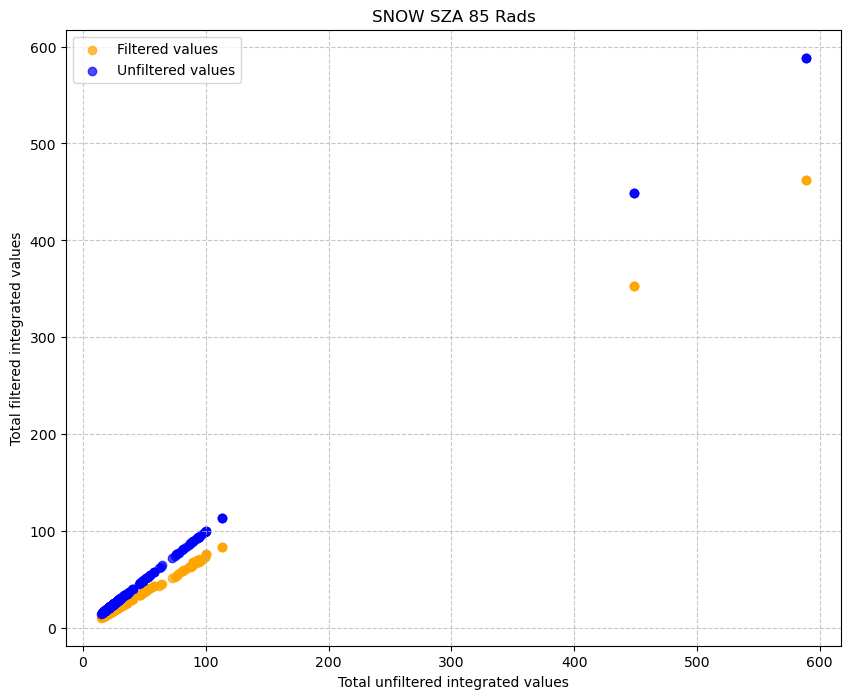

In [26]:
test = plot_scene_radiation(a85_ds, "Snow")

In [18]:
test["df"]

,Scene,SZA,VZA,RAZ,Cloud,Run #,Shortwave Unfiltered Rads (Integrated),Longwave Unfiltered Rads (Integrated),Shortwave Filtered Rads (Integrated),Longwave Filtered Rads (Integrated)
0,Snow,84.822,0.000,0.0,0,0,21.773407,64.163561,16.059889,41.737298
1,Snow,84.822,0.000,0.0,1,1,17.434016,61.352730,12.731470,39.954763
2,Snow,84.822,0.000,0.0,1,2,16.020029,65.101014,11.556593,42.320141
3,Snow,84.822,0.000,0.0,1,3,23.183928,53.795441,17.244129,35.158961
4,Snow,84.822,0.000,0.0,1,4,18.993875,63.364916,13.924595,41.263277
...,...,...,...,...,...,...,...,...,...,...
310,Snow,83.928,89.947,172.5,0,310,72.642480,55.204991,51.297390,35.892922
311,Snow,83.928,89.947,172.5,1,311,92.298272,42.378937,67.032751,27.649945
312,Snow,83.928,89.947,172.5,1,312,87.839910,53.257830,63.199045,34.697747
313,Snow,83.928,89.947,172.5,1,313,113.020691,47.220680,83.440846,30.930216


In [19]:
snow.describer_df

,Scene,SZA,VZA,RAZ,Cloud,Run #,Shortwave Unfiltered Rads (Integrated),Longwave Unfiltered Rads (Integrated),Shortwave Filtered Rads (Integrated),Longwave Filtered Rads (Integrated)
0,Snow,84.822,0.000,0.0,0,0,21.773407,64.163561,16.059889,41.737298
1,Snow,84.822,0.000,0.0,1,1,17.434016,61.352730,12.731470,39.954763
2,Snow,84.822,0.000,0.0,1,2,16.020029,65.101014,11.556593,42.320141
3,Snow,84.822,0.000,0.0,1,3,23.183928,53.795441,17.244129,35.158961
4,Snow,84.822,0.000,0.0,1,4,18.993875,63.364916,13.924595,41.263277
...,...,...,...,...,...,...,...,...,...,...
310,Snow,83.928,89.947,172.5,0,310,72.642480,55.204991,51.297390,35.892922
311,Snow,83.928,89.947,172.5,1,311,92.298272,42.378937,67.032751,27.649945
312,Snow,83.928,89.947,172.5,1,312,87.839910,53.257830,63.199045,34.697747
313,Snow,83.928,89.947,172.5,1,313,113.020691,47.220680,83.440846,30.930216


In [22]:
test["filtered"]

0      16.059889
1      12.731470
2      11.556593
3      17.244129
4      13.924595
         ...    
310    51.297390
311    67.032751
312    63.199045
313    83.440846
314    67.786319
Name: Shortwave Filtered Rads (Integrated), Length: 315, dtype: float64

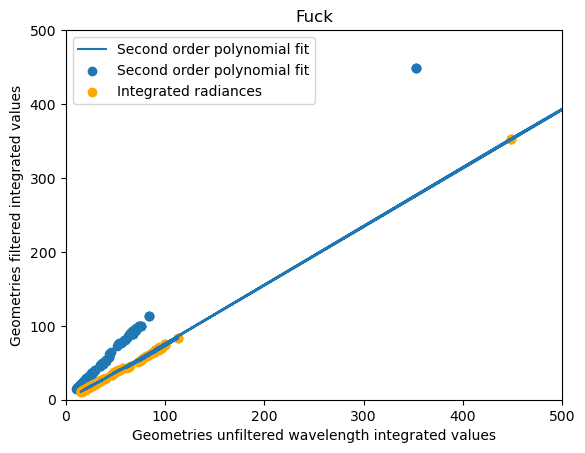

In [29]:
plt.plot(test["unfiltered"], test["filtered"]) #Plot of integrated vs filtered data
plt.scatter(test["filtered"], test["unfiltered"]) #Scattered points of filtered versus unfiltered data
plt.scatter(test["unfiltered"], test["filtered"], color = "orange") #Scattered points of integrated sw versus filtered data
plt.xlabel("Geometries unfiltered wavelength integrated values")
plt.ylabel("Geometries filtered integrated values")
plt.xlim([0,500])
plt.ylim([0,500])
plt.title("Fuck")

plt.legend(["Second order polynomial fit", "Second order polynomial fit", "Integrated radiances"])
plt.show()

In [34]:
for i in snow.rads[0][0]:
    print(i)

0.25
0.2500625156289072
0.25012506253126565
0.25018764073054794
0.2502502502502503
0.2503128911138924
0.25037556334501754
0.2504382669671926
0.250501002004008
0.25056376847907796
0.2506265664160401
0.25068939583855604
0.25075225677031093
0.2508151492350138
0.2508780732563974
0.25094102885821834
0.25100401606425704
0.25106703489831783
0.25113008538422904
0.25119316754584275
0.25125628140703515
0.25131942699170645
0.2513826043237808
0.25144581342720645
0.2515090543259557
0.25157232704402516
0.25163563160543534
0.2516989680342311
0.25176233635448136
0.2518257365902795
0.2518891687657431
0.25195263290501385
0.25201612903225806
0.25207965717166625
0.2521432173474533
0.25220680958385877
0.2522704339051463
0.25233409033560433
0.2523977788995457
0.25246149962130776
0.25252525252525254
0.2525890376357666
0.25265285497726125
0.25271670457417234
0.2527805864509606
0.2528445006321113
0.25290844714213456
0.25297242600556535
0.25303643724696356
0.2531004808909137
0.25316455696202533
0.25322866548493

In [36]:
import pickle
with open('./data/scne_integrated_sw-sno85.spydata', 'rb') as f:
    data = pickle.load(f)

UnpicklingError: unpickling stack underflow

In [37]:
snow.rads.shape

(315, 3, 4000)